epoch: 001// total loss: 0.158909// mse loss: 0.000492//  domain loss: 0.176511
epoch: 002// total loss: 0.331018// mse loss: 0.000078//  domain loss: 0.367789
epoch: 003// total loss: 0.292290// mse loss: 0.000054//  domain loss: 0.324761
epoch: 004// total loss: 0.394166// mse loss: 0.000034//  domain loss: 0.437959
epoch: 005// total loss: 0.172181// mse loss: 0.000034//  domain loss: 0.191309
epoch: 006// total loss: 0.194236// mse loss: 0.000029//  domain loss: 0.215815
epoch: 007// total loss: 0.156731// mse loss: 0.000028//  domain loss: 0.174142
epoch: 008// total loss: 0.183783// mse loss: 0.000029//  domain loss: 0.204200
epoch: 009// total loss: 0.163494// mse loss: 0.000029//  domain loss: 0.181657
epoch: 010// total loss: 0.265840// mse loss: 0.000030//  domain loss: 0.295375
epoch: 011// total loss: 0.150083// mse loss: 0.000029//  domain loss: 0.166755
epoch: 012// total loss: 0.356500// mse loss: 0.000028//  domain loss: 0.396108
epoch: 013// total loss: 0.183108// mse 

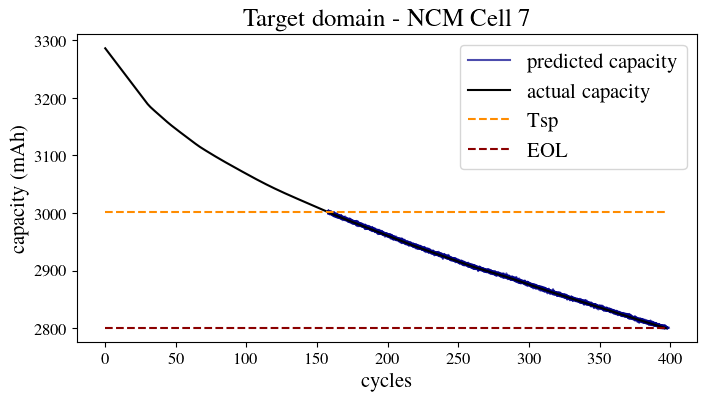

Target domain capacity - NCM Cell 7// Actual RUL: 241// Predicted RUL: [234.5913, 243.8087]
AE: 1.8000// RE: 0.0075


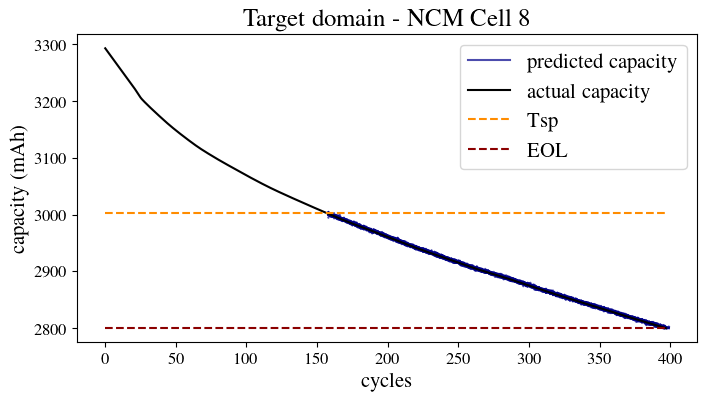

Target domain capacity - NCM Cell 8// Actual RUL: 241// Predicted RUL: [233.6957, 244.3709]
AE: 1.9667// RE: 0.0082


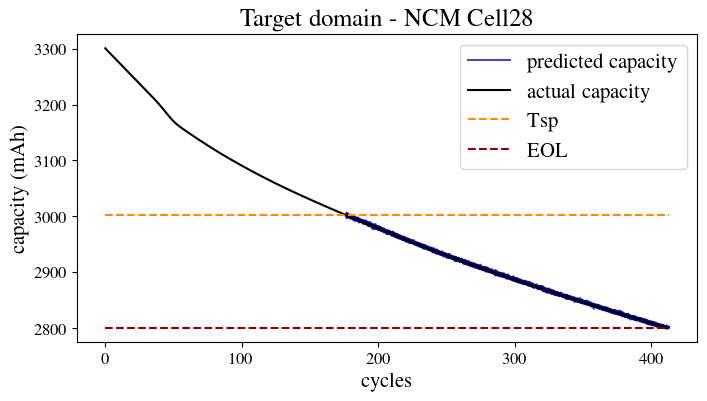

Target domain capacity - NCM Cell28// Actual RUL: 237// Predicted RUL: [230.7567, 239.3100]
AE: 1.9667// RE: 0.0083


In [ ]:
import os, torch, warnings, time
from tools import  real_csvfiles_in_folder
from tools import  data_smoothing
from tools import  get_Tsp
# from tools import  get_figure1
from tools import  sliding_window_approach
from tools import  data_normalization
from tools import partial_dataset_generator
from tools import train_dataset_generator
from tools import SoftDTWLoss
from tools import get_figure
# from tools import get_inference_figure
import pandas as pd
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from xlstm import sLSTM
import matplotlib
plt.rcParams["font.family"] = "Times New Roman"
warnings.filterwarnings("ignore")
matplotlib.rcParams.update({"text.usetex": True,"font.family": "serif", "font.serif": ["Times New Roman"], "text.latex.preamble": r"\usepackage{mathptmx}"})

class EnLSTM(nn.Module):
    def __init__(self, in_dim, head_size, num_heads, model_mode= "train"):
        super(EnLSTM, self).__init__()
        self.in_dim, self.device= in_dim, device
        self.head_size, self.num_heads= head_size, num_heads
        self.is_train= True if model_mode== "train" else False
        self.lstm= sLSTM(input_size= self.in_dim, head_size= self.head_size, num_heads= self.num_heads, num_layers=1, batch_first= False, proj_factor=4/3)
    def gussain_noise_layer(self, input, mean= 0.0, standard_deviaton= 0.005):
        if self.is_train:
            noise= input.data.new(input.size()).normal_(mean, standard_deviaton)
            return noise+ input
        return input
    def forward(self, input_x):
        input_x= self.gussain_noise_layer(input_x)
        lstm_output, _= self.lstm(input_x)
        lstm_output= lstm_output[:, -1, :]
        return lstm_output
    
class DnnPredictor(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_layer_size, dropout_rate, is_train= False):
        super(DnnPredictor, self).__init__()
        self.in_dim, self.out_dim, self.hidden_layer_size, self.is_train= in_dim, out_dim, hidden_layer_size, is_train
        self.dense1= nn.Linear(in_dim, self.hidden_layer_size["dense_layer_1"])
        self.dense2= nn.Linear(self.hidden_layer_size["dense_layer_1"], self.hidden_layer_size["dense_layer_2"])
        self.dropout_layer= nn.Dropout(p= dropout_rate)
        self.ReLU= nn.ReLU()
        self.output_layer= nn.Linear(self.hidden_layer_size["dense_layer_2"], out_dim)
    def gussain_noise_layer(self, input, mean= 0.0, standard_deviaton= 0.005):
        if self.is_train:
            noise= input.data.new(input.size()).normal_(mean, standard_deviaton)
            return noise+ input
        return input
    def forward(self, input_x):
        output= nn.functional.relu(input_x)
        output= self.dense1(output)
        output= self.dropout_layer(output)
        output= self.ReLU(output)
        output= self.dense2(output)
        output= self.dropout_layer(output)
        output= self.ReLU(output)
        output= self.output_layer(output)
        output= self.gussain_noise_layer(output)
        # output= torch.abs(nn.functional.tanh(output))
        output= nn.functional.tanh(output)
        return output

def partial_before_dataset_generator(dataset: pd.DataFrame, Tsp: float):
    cell_ls= np.unique(dataset["Cell"]); partial_dataset= pd.DataFrame()
    for cell_name in cell_ls:
        cell_data= dataset[dataset["Cell"]== cell_name]
        cell_data= cell_data[cell_data["Capacity"]>= Tsp]
        partial_dataset= pd.concat([partial_dataset, cell_data], axis= 0)
    partial_dataset= partial_dataset.reset_index(drop= True)
    return partial_dataset

def partial_after_dataset_generator(dataset: pd.DataFrame, Tsp_capacity: float, window_size: int):
    cell_ls= np.unique(dataset["Cell"]); partial_dataset= pd.DataFrame()
    for cell_name in cell_ls:
        cell_data= dataset[dataset["Cell"]== cell_name]
        cell_data= cell_data.iloc[len(cell_data[cell_data["Capacity"]>= Tsp_capacity])- window_size: , :]
        partial_dataset= pd.concat([partial_dataset, cell_data], axis= 0)
    partial_dataset= partial_dataset.reset_index(drop= True)
    return partial_dataset

def get_prediction(encoder, predictor, x, normalizer):
    with torch.no_grad():
        pred_capacity_fade= predictor(encoder(x))
    pred_capacity_fade= pred_capacity_fade.data.cpu().numpy().ravel()
    x= x.data.cpu().numpy()
    predicted_capacity= pred_capacity_fade+ x[:, : , 0][:, -1]
    predicted_capacity= normalizer.inverse_transform(predicted_capacity.reshape(-1, 1))
    return predicted_capacity.ravel()

if __name__== "__main__":
    device= "cuda" if torch.cuda.is_available else "cpu"
    dataset_folder= os.path.join(os.getcwd(), "../", "datasets")
    normal_capacity= 3500
    sliding_window_size= 3
    EOL_capacity= normal_capacity* 0.8
    ### set up the source and target dataset name for the experiement.
    SOURCE_DOMAIN= "nca-45"; TARGET_DOMAIN= "ncm-45"
    SOURCE_CELLS= ["NCA cell#23", "NCA cell#24", "NCA cell#22", "NCA cell#18", "NCA cell#12", "NCA cell#13", "NCA cell#20", "NCA cell#14"]
    SOURCE_CELLS= [cell.split(" ")[0]+ " "+ "Cell%2d"%(int(cell.split("#")[-1])) for cell in SOURCE_CELLS]
    TARGET_CELLS= ["NCM cell#28", "NCM cell#08", "NCM cell#07"]
    TARGET_CELLS= [cell.split(" ")[0]+ " "+ "Cell%2d"%(int(cell.split("#")[-1])) for cell in TARGET_CELLS]
    ### get source full curve dataset
    source_full_cell_dataset= real_csvfiles_in_folder(os.path.join(dataset_folder, SOURCE_DOMAIN.split("-")[0], SOURCE_DOMAIN.split("-")[1]))
    source_full_cell_dataset= data_smoothing(dataset= source_full_cell_dataset, lowess_tau= 1/10, verbose= False)
    ### get Tsp using bacon-watte model
    source_full_cell_dataset["Capacity"]= source_full_cell_dataset["Capacity"]/ normal_capacity
    source_full_cell_dataset=source_full_cell_dataset[source_full_cell_dataset["Cell"].isin(SOURCE_CELLS)]
    Tsp, Tsp_capacity= get_Tsp(source_full_cell_dataset)
    Tsp_capacity= Tsp_capacity* normal_capacity
    source_full_cell_dataset["Capacity"]= source_full_cell_dataset["Capacity"]* normal_capacity
    ### get source partial curve dataset
    source_partial_cell_dataset= partial_dataset_generator(dataset= source_full_cell_dataset, Tsp= Tsp_capacity)
    source_partial_cell_dataset= source_partial_cell_dataset[source_partial_cell_dataset["Cell"].isin(SOURCE_CELLS)]
    ### get target partial curve dataset
    target_full_cell_dataset= real_csvfiles_in_folder(os.path.join(dataset_folder, TARGET_DOMAIN.split("-")[0], TARGET_DOMAIN.split("-")[1]))
    target_full_cell_dataset= data_smoothing(dataset= target_full_cell_dataset, lowess_tau= 1/10, verbose= False)
    target_partial_cell_dataset= partial_dataset_generator(dataset= target_full_cell_dataset, Tsp= Tsp_capacity)
    target_partial_cell_dataset= target_partial_cell_dataset[target_partial_cell_dataset["Cell"].isin(TARGET_CELLS)]
    del target_full_cell_dataset
    # TODO  get_figure1(SOURCE_DOMAIN, TARGET_DOMAIN, source_full_cell_dataset, source_partial_cell_dataset, target_partial_cell_dataset, normal_capacity, Tsp_capacity)
    ### data-preprocessing for source full dataset.
    source_full_cell_dataset, source_full_cell_dataset_normalizer= data_normalization(dataset= source_full_cell_dataset)
    source_full_cell_dataset= sliding_window_approach(dataset= source_full_cell_dataset, m= sliding_window_size)
    ### data-preprocessing for source partial dataset.
    source_partial_cell_dataset, source_partial_cell_dataset_normalizer= data_normalization(dataset= source_partial_cell_dataset)
    source_partial_cell_dataset= sliding_window_approach(dataset= source_partial_cell_dataset, m= sliding_window_size)
    ### data-preprocessing for target partial dataset.
    target_partial_cell_dataset, target_partial_cell_dataset_normalizer= data_normalization(dataset= target_partial_cell_dataset)
    target_partial_cell_dataset= sliding_window_approach(dataset= target_partial_cell_dataset, m= sliding_window_size)
    #################################################################################################################
    epochs= 100; learning_rate= 0.001; dropout_rate= 0.01; num_features= 1; batch_size= 1024
    lambda_D= 0.9; lambda_T= 0.1; lambda_S= 0.1; lambda_P= 0.1
    hidden_size= {"dense_layer_1": 64, "dense_layer_2": 64, "output_layer": 1}
    Encoder= EnLSTM(in_dim= 1, head_size= 64, num_heads= 1, model_mode= "train").to(device)
    Predictor= DnnPredictor(in_dim= 64, out_dim= 1, hidden_layer_size= hidden_size, dropout_rate= dropout_rate, is_train= "train").to(device)
    mse_loss_function= nn.MSELoss()
    domain_loss_function= SoftDTWLoss(gamma= 0.1, normalize= True).to(device)
    Eoptimizer= torch.optim.Adam(Encoder.parameters(), lr= learning_rate)
    Poptimizer= torch.optim.Adam(Predictor.parameters(), lr= learning_rate)
    total_loss_ls= []; predictor_loss_ls= [];  domain_loss_ls= []; epoch_time_ls= []
    source_cell_name_ls, target_cell_name_ls= np.unique(source_full_cell_dataset["cell"]), np.unique(target_partial_cell_dataset["cell"])
    early_stopping= {"best_epoch": 0, "best_loss": np.inf, "count": 0}
    s_time= time.time()
    for e in range(1, epochs+ 1):
        Encoder.train(); Predictor.train(); batch_mean_square_error_loss= []; batch_domain_loss= []; batch_target_predictor_mean_loss= []; batch_total_loss= []
        for target_cell_name in target_cell_name_ls:
            for source_cell_name in np.random.choice(source_cell_name_ls, len(target_cell_name_ls), replace= False):
                Eoptimizer.zero_grad(); Poptimizer.zero_grad()
                source_full_single_cell_dataset= source_full_cell_dataset[source_full_cell_dataset["cell"]== source_cell_name]
                source_full_lstm_x, source_full_lstm_y= train_dataset_generator(dataset= source_full_single_cell_dataset, num_features= num_features)
                source_full_lstm_x, source_full_lstm_y= torch.FloatTensor(source_full_lstm_x).to(device), torch.FloatTensor(source_full_lstm_y).to(device)
                Sfull_domain_y= Predictor(Encoder(source_full_lstm_x)).ravel()
                mean_square_error_loss= mse_loss_function(Sfull_domain_y, source_full_lstm_y)
                target_partial_single_cell_dataset= target_partial_cell_dataset[target_partial_cell_dataset["cell"]== target_cell_name]
                target_partial_lstm_x, target_partial_lstm_y= train_dataset_generator(dataset= target_partial_single_cell_dataset, num_features= num_features)
                target_partial_lstm_x= torch.FloatTensor(target_partial_lstm_x).to(device)
                # target_partial_lstm_y= torch.FloatTensor(target_partial_lstm_y).to(device)
                source_partial_single_cell_dataset= source_partial_cell_dataset[source_partial_cell_dataset["cell"]== source_cell_name]
                source_partial_lstm_x, source_partial_lstm_y= train_dataset_generator(dataset= source_partial_single_cell_dataset, num_features= num_features)
                source_partial_lstm_x= torch.FloatTensor(source_partial_lstm_x).to(device)
                # source_partial_lstm_y= torch.FloatTensor(source_partial_lstm_y).to(device)
                Tdomain_y= Predictor(Encoder(target_partial_lstm_x)).ravel()
                Sdomain_y= Predictor(Encoder(source_partial_lstm_x)).ravel()
                domain_loss= domain_loss_function(Sdomain_y.unsqueeze(0).unsqueeze(-1), Tdomain_y.unsqueeze(0).unsqueeze(-1))
                total_loss= lambda_D* domain_loss+ lambda_P* mean_square_error_loss
                total_loss.backward()
                Eoptimizer.step(); Poptimizer.step()
                batch_mean_square_error_loss.append(mean_square_error_loss.item())
                batch_domain_loss.append(domain_loss.item())
                batch_total_loss.append(total_loss.item())
        print("epoch: %03d// total loss: %2.6f// mse loss: %2.6f//  domain loss: %2.6f"%(e, np.mean(batch_total_loss), np.mean(batch_mean_square_error_loss), np.mean(batch_domain_loss)))
        if e% 1== 0:
            Encoder.eval(); Predictor.eval()
            # source_full_single_cell_dataset= source_full_cell_dataset[source_full_cell_dataset["cell"]== source_cell_name]
            # source_full_lstm_x, source_full_lstm_y= train_dataset_generator(dataset= source_full_single_cell_dataset, num_features= num_features)
            # source_full_lstm_x, source_full_lstm_y= torch.FloatTensor(source_full_lstm_x).to(device), torch.FloatTensor(source_full_lstm_y).to(device)
            # with torch.no_grad():
            #     pred_capacity_fade= Predictor(Encoder(source_full_lstm_x))
            # pred_capacity_fade= pred_capacity_fade.data.cpu().numpy().ravel()
            # source_full_lstm_x= source_full_lstm_x.data.cpu().numpy()
            # predicted_capacity= pred_capacity_fade+ source_full_lstm_x[:, : , 0][:, -1]
            # predicted_capacity= source_full_cell_dataset_normalizer.inverse_transform(predicted_capacity.reshape(-1, 1))
            # actual_capacity= source_full_lstm_y.data.cpu().numpy()+ source_full_lstm_x[:, : , 0][:, -1]
            # actual_capacity= source_full_cell_dataset_normalizer.inverse_transform(actual_capacity.reshape(-1, 1))
            target_partial_single_cell_dataset= target_partial_cell_dataset[target_partial_cell_dataset["cell"]== target_cell_name]
            target_partial_lstm_x, target_partial_lstm_y= train_dataset_generator(dataset= target_partial_single_cell_dataset, num_features= num_features)
            target_partial_lstm_x, target_partial_lstm_y= torch.FloatTensor(target_partial_lstm_x).to(device), torch.FloatTensor(target_partial_lstm_y).to(device)
            with torch.no_grad():
                pred_capacity_fade= Predictor(Encoder(target_partial_lstm_x))
            pred_capacity_fade= pred_capacity_fade.data.cpu().numpy().ravel()
            target_partial_lstm_x= target_partial_lstm_x.data.cpu().numpy()
            predicted_capacity= pred_capacity_fade+ target_partial_lstm_x[:, : , 0][:, -1]
            predicted_capacity= target_partial_cell_dataset_normalizer.inverse_transform(predicted_capacity.reshape(-1, 1))
            actual_capacity= target_partial_lstm_y.data.cpu().numpy()+  target_partial_lstm_x[:, : , 0][:, -1]
            actual_capacity= target_partial_cell_dataset_normalizer.inverse_transform(actual_capacity.reshape(-1, 1))
            Tpartial_valid_loss= np.mean((predicted_capacity- actual_capacity)** 2)
            if Tpartial_valid_loss< early_stopping["best_loss"]:
                # get_figure(actual= actual_capacity, preidction= predicted_capacity, figure_title= "Source full length capacity")
                # get_figure(actual= actual_capacity, preidction= predicted_capacity, figure_title= "Target partial length capacity")
                early_stopping["best_loss"]= Tpartial_valid_loss
                early_stopping["best_epoch"]= e
                early_stopping["count"]= 0
                torch.save(Encoder, os.path.join(os.getcwd(), "encoder-dtw.pth")); torch.save(Predictor, os.path.join(os.getcwd(), "predictor-dtw.pth"))
            else:
                early_stopping["count"]+= 1
            if early_stopping["count"]== 10:
                print("best model at epoch: %03d// target partial validation loss: %2.6f"%(early_stopping["best_epoch"], early_stopping["best_loss"]))
                break
    e_time= time.time()
    print("Time consuming (Training): %05.4f sec"%(e_time- s_time))
    Encoder.eval(); Predictor.eval()
    monte_carlo= 30
    target_full_cell_dataset= real_csvfiles_in_folder(os.path.join(dataset_folder, TARGET_DOMAIN.split("-")[0], TARGET_DOMAIN.split("-")[1]))
    target_full_cell_dataset= data_smoothing(dataset= target_full_cell_dataset, lowess_tau= 1/10, verbose= False)
    target_partial_before_cell_dataset= partial_before_dataset_generator(dataset= target_full_cell_dataset, Tsp= Tsp_capacity)
    target_partial_before_cell_dataset= target_partial_before_cell_dataset[target_partial_before_cell_dataset["Cell"].isin(TARGET_CELLS)]
    target_partial_before_cell_dataset, target_partial_before_cell_dataset_normalizer= data_normalization(dataset= target_partial_before_cell_dataset)
    target_partial_before_cell_dataset= sliding_window_approach(dataset= target_partial_before_cell_dataset, m= sliding_window_size)
    target_partial_after_cell_dataset= partial_after_dataset_generator(dataset= target_full_cell_dataset, Tsp_capacity= Tsp_capacity, window_size= sliding_window_size)
    target_partial_after_cell_dataset= target_partial_after_cell_dataset[target_partial_after_cell_dataset["Cell"].isin(TARGET_CELLS)]
    target_partial_after_cell_dataset["Capacity"]= target_partial_before_cell_dataset_normalizer.transform(target_partial_after_cell_dataset[["Capacity"]])
    target_partial_after_cell_dataset= sliding_window_approach(dataset= target_partial_after_cell_dataset, m= sliding_window_size)
    for target_cell_name in target_cell_name_ls:
        target_partial_single_after_cell_dataset= target_partial_after_cell_dataset[target_partial_after_cell_dataset["cell"]== target_cell_name]
        target_partial_single_after_lstm_x, target_partial_single_after_lstm_y= train_dataset_generator(dataset= target_partial_single_after_cell_dataset, num_features= num_features)
        target_partial_single_after_lstm_x= torch.FloatTensor(target_partial_single_after_lstm_x).to(device)
        plt.figure(figsize= (8, 4))
        plt.title("Target domain - %s"%(target_cell_name), fontsize= 18)
        count= 0; predicted_RUL_ls= []
        actual_capacity= target_full_cell_dataset[target_full_cell_dataset["Cell"]== target_cell_name]["Capacity"].values
        actual_capacity= actual_capacity[: np.where(actual_capacity<= EOL_capacity)[0][0]]
        Tsp= np.where(actual_capacity<= Tsp_capacity)[0][0]
        for simulation_i in range(0, monte_carlo):
            predicted_capacity= get_prediction(Encoder, Predictor, target_partial_single_after_lstm_x, target_partial_before_cell_dataset_normalizer)
            predicted_capacity= predicted_capacity.ravel()
            try:
                predicted_capacity= predicted_capacity[: np.where(predicted_capacity<= EOL_capacity)[0][0]]
                predicted_RUL_ls.append(len(predicted_capacity))
            except Exception as e:
                predicted_capacity= predicted_capacity
                predicted_RUL_ls.append(len(predicted_capacity))
            if count== 0: 
                plt.plot(np.arange(Tsp, Tsp+ len(predicted_capacity)), predicted_capacity, color= "darkblue", label= "predicted capacity", alpha= 0.7); count+= 1
            else: 
                plt.plot(np.arange(Tsp, Tsp+ len(predicted_capacity)), predicted_capacity, color= "darkblue", alpha= 0.7)
        actual_RUL= len(actual_capacity[np.where(actual_capacity>= Tsp_capacity)[0][-1]: ])
        predicted_RUL= [np.mean(predicted_RUL_ls)- 3* np.std(predicted_RUL_ls), np.mean(predicted_RUL_ls)+ 3* np.std(predicted_RUL_ls)]
        plt.plot(np.arange(0, len(actual_capacity)), actual_capacity, color= "black", label= "actual capacity")
        plt.hlines(Tsp_capacity, 0, max([len(actual_capacity), len(predicted_capacity)]), color= "darkorange", ls= "--", label= "Tsp")
        plt.hlines(EOL_capacity, 0, max([len(actual_capacity), len(predicted_capacity)]), color= "darkred", ls= "--", label= "EOL")
        plt.legend(loc= "best", fontsize= 15)
        plt.xlabel("cycles", fontsize= 15)
        plt.ylabel("capacity (mAh)", fontsize= 15)
        plt.xticks(fontsize= 12)
        plt.yticks(fontsize= 12)
        plt.show()
        print("Target domain capacity - %s// Actual RUL: %02d// Predicted RUL: [%2.4f, %2.4f]"%(target_cell_name, actual_RUL, predicted_RUL[0], predicted_RUL[1]))
        print("AE: %2.4f// RE: %2.4f"%(np.abs(actual_RUL- np.mean(predicted_RUL_ls)), np.abs(actual_RUL- np.mean(predicted_RUL_ls))/ actual_RUL))

In [ ]:
3245/ 60

54.083333333333336